Here, we compare Logistic Regression, XGBoost, SVC, and RandomForest's performance via nestedCV.

# Imports

In [1]:
import pandas as pd
import numpy as np

# Get and Format Data

In [2]:
def prepare_data(data, year):
    data = data.rename(columns=lambda x: x[2:] if x[1]=='_' else x)
    data['year'] = year
    data = data.sample(frac=1)
    return data

In [18]:
amazon_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/amazon_train_{year}_lag0.csv"), year) for year in range(2022, 2025)]
amazon_train = pd.concat(amazon_train_sets, axis=0)

taiga_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/taiga_train_{year}_lag0.csv"), year) for year in range(2022, 2025)]
taiga_train = pd.concat(taiga_train_sets, axis=0)

borneo_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/borneo_train_{year}_lag0.csv"), year) for year in range(2022, 2025)]
borneo_train = pd.concat(borneo_train_sets, axis=0)

train_set = pd.concat([amazon_train, taiga_train, borneo_train], axis=0)
train_set = train_set.sample(frac=1)
train_set = train_set.sort_values(by='year')
print(train_set.head())
# print(train_set.groupby('year')['class'].count())

     system:index  NBR_delta_lag4  NBR_lag4  NDMI_delta_lag4  NDMI_lag4  \
4991     2_2020_0        0.006696  0.337332        -0.001004   0.209545   
5257     2_2381_0        0.026120  0.365447         0.018994   0.236889   
1130     1_4149_0       -0.003118  0.383215        -0.000724   0.240564   
2276     1_5276_0       -0.044439  0.195347        -0.069966   0.105563   
990      1_3990_0        0.052658  0.323914         0.088227   0.251411   

      NDVI_delta_lag4  NDVI_lag4  SR_B4_delta_lag4  SR_B4_lag4  \
4991         0.004756   0.384879              20.5      8071.0   
5257         0.023090   0.398190            -454.0      8144.0   
1130         0.002513   0.442785              70.0      8216.0   
2276        -0.025502   0.228397              34.5      8358.0   
990         -0.121975   0.207079            3396.5     11941.0   

      SR_B5_delta_lag4  ...  NDVI_lag0  SR_B4_lag0  SR_B5_lag0  SR_B6_lag0  \
4991             247.0  ...   0.380123      8050.5     17924.0     11689.0

In [26]:
print(amazon_train[['NBR_lag4', 'NBR_delta_lag4', 'NBR_lag0']].head())

      NBR_lag4  NBR_delta_lag4  NBR_lag0
2361  0.379680        0.031365  0.348315
1934  0.365852        0.020294  0.345558
4668  0.352074       -0.008183  0.360256
5116  0.363037        0.051838  0.311199
711   0.351244        0.102060  0.249185


# Feature Selection

In [42]:
# select all feature columns except metadata/target columns
exclude_cols = {'index', 'system:index', 'class', 'latitude', 'longitude', '.geo', 'year'}
all_features = [c for c in train_set.columns if c not in exclude_cols]
# drop columns ending with "delta_lag1"
# drop_cols = [c for c in train_set.columns if c.endswith('delta_lag1')]
# train_set = train_set.drop(columns=drop_cols)
# all_features = [c for c in all_features if c not in drop_cols]
# print(f"Dropped {len(drop_cols)} columns: {drop_cols}")

recent_features = ['NBR_delta_lag1', 'NBR_lag1',
       'NDMI_delta_lag1', 'NDMI_lag1', 'NDVI_delta_lag1', 'NDVI_lag1',
       'SR_B4_delta_lag1', 'SR_B4_lag1', 'SR_B5_delta_lag1', 'SR_B5_lag1',
       'SR_B6_delta_lag1', 'SR_B6_lag1', 'SR_B7_delta_lag1', 'SR_B7_lag1',
       'NBR_lag0', 'NDMI_lag0', 'NDVI_lag0', 'SR_B4_lag0', 'SR_B5_lag0',
       'SR_B6_lag0', 'SR_B7_lag0']

In [43]:
X_train = train_set[recent_features]
y_train = train_set['class']
print(X_train.columns)

Index(['NBR_delta_lag1', 'NBR_lag1', 'NDMI_delta_lag1', 'NDMI_lag1',
       'NDVI_delta_lag1', 'NDVI_lag1', 'SR_B4_delta_lag1', 'SR_B4_lag1',
       'SR_B5_delta_lag1', 'SR_B5_lag1', 'SR_B6_delta_lag1', 'SR_B6_lag1',
       'SR_B7_delta_lag1', 'SR_B7_lag1', 'NBR_lag0', 'NDMI_lag0', 'NDVI_lag0',
       'SR_B4_lag0', 'SR_B5_lag0', 'SR_B6_lag0', 'SR_B7_lag0'],
      dtype='object')


class               1.000000
SR_B6_lag0          0.214560
SR_B7_lag0          0.203455
SR_B6_lag1          0.185864
SR_B7_lag1          0.174223
SR_B5_lag1          0.105762
NDMI_lag0           0.098813
SR_B4_lag0          0.095570
SR_B5_lag0          0.091429
NDMI_delta_lag1     0.070788
SR_B4_lag1          0.062926
NDVI_lag1           0.060599
NBR_delta_lag1      0.055555
SR_B6_delta_lag1    0.052804
NDMI_lag1           0.050424
SR_B7_delta_lag1    0.048495
NDVI_delta_lag1     0.045748
NBR_lag0            0.045040
NDVI_lag0           0.027572
SR_B4_delta_lag1    0.026486
SR_B5_delta_lag1    0.018386
NBR_lag1            0.006022
Name: class, dtype: float64


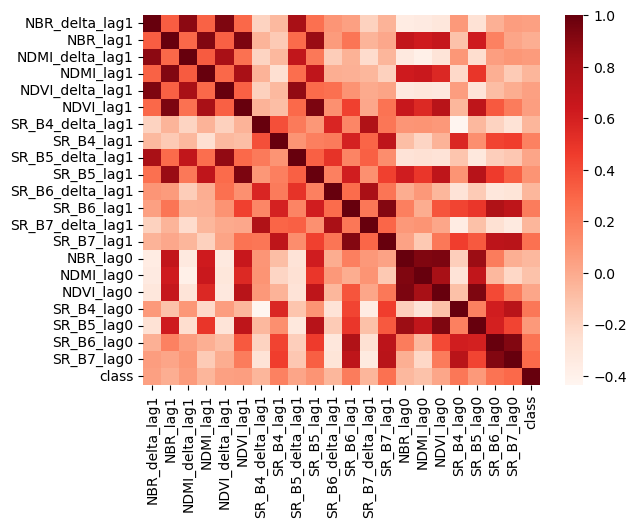

In [44]:
import seaborn as sns
sns.heatmap(pd.concat([amazon_train[recent_features], amazon_train['class']], axis=1).corr(method='spearman'), cmap='Reds')
print(abs(pd.concat([amazon_train[recent_features], amazon_train['class']], axis=1).corr()['class']).sort_values(ascending=False))

Features not well correlated...

# Compare Models

In [45]:
def custom_year_ts_split(df, year_col):
    """Custom CV splitter for our yearly data."""
    # Get unique years and sort them
    years = sorted(df[year_col].unique())
    
    # We need at least 2 years to do one split (Train Y1 -> Val Y2)
    for i in range(1, len(years)):
        # Training set: All years up to the current split
        train_indices = df[df[year_col].isin(years[:i])].index.values
        
        # Validation set: The very next year
        val_indices = df[df[year_col] == years[i]].index.values
        yield train_indices, val_indices

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import cross_validate


## Logistic Regression

In [34]:

cv_iterator = custom_year_ts_split(train_set, 'year')
logistic_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', LogisticRegressionCV(
        cv=5, 
        l1_ratios=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], 
        max_iter=5000,
        solver='saga',
        random_state=1,
        use_legacy_attributes=False))])
logistic_results = cross_validate(
    logistic_pipe, 
    X_train, 
    y_train, 
    cv=cv_iterator, 
    return_estimator=True,
    scoring=['f1', 'precision', 'recall'], 
    return_train_score=True,  # Crucial for detecting overfitting
    verbose=10,
)

KeyboardInterrupt: 

In [ ]:
print(f"Mean Test f1: {logistic_results['test_f1'].mean():.4f}")
print(f"Mean Test Precision: {logistic_results['test_precision'].mean():.4f}")
print(f"Mean Test Recall: {logistic_results['test_recall'].mean():.4f}")

print(f"Mean Train f1: {logistic_results['train_f1'].mean():.4f}")
print(f"Mean Train Precision: {logistic_results['train_precision'].mean():.4f}")
print(f"Mean Train Recall: {logistic_results['train_recall'].mean():.4f}")

print(f"Overfitting Ratio: {1-logistic_results['test_f1'].mean()/logistic_results['train_f1'].mean()}")

Mean Test f1: 0.5798
Mean Test Precision: 0.6111
Mean Test Recall: 0.5520
Mean Train f1: 0.6529
Mean Train Precision: 0.6421
Mean Train Recall: 0.6640
Overfitting Ratio: 0.11185901085749628


Logistic Regression exhibits bad f1 scores with high overfitting.

## XGBoost

In [47]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier

In [48]:
xgboost_param_grid = {
    'model__max_depth': Integer(3, 5),
    'model__min_child_weight': Integer(1, 200),
    'model__subsample': Real(0.7, 1),
    'model__colsample_bylevel': Real(0.5, 1),
    'model__colsample_bynode': Real(0.5, 1),
    'model__reg_lambda': Real(0, 10),
    'model__reg_alpha': Real(0, 10)
}

In [49]:
xgb_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', XGBClassifier(objective='binary:logistic', random_state=1, learning_rate=0.3, tree_method='hist'))
])

tuner = BayesSearchCV(
    estimator=xgb_pipe,
    cv=5,
    n_iter=32,
    refit='f1',
    search_spaces=xgboost_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1',
)

cv_iterator = custom_year_ts_split(train_set, 'year')

xgb_results = cross_validate(
    tuner,
    X_train, 
    y_train, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [50]:
# Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
for outer_fold, outer_estimator in enumerate(xgb_results['estimator'], start=1):
    search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
    inner_results = pd.DataFrame(search.cv_results_)
    best_idx = search.best_index_

    print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
    mean_test = inner_results.loc[best_idx, "mean_test_score"]
    std_test = inner_results.loc[best_idx, "std_test_score"]
    print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
    print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

    if "mean_train_score" in inner_results.columns:
        mean_train = inner_results.loc[best_idx, "mean_train_score"]
        std_train = inner_results.loc[best_idx, "std_train_score"]
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
        print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_test:.6f}")
    else:
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {xgb_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {xgb_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {xgb_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {xgb_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {xgb_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {xgb_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-xgb_results['test_f1'].mean()/xgb_results['train_f1'].mean()}")

Outer Fold 1 Parameters - OrderedDict({'model__colsample_bylevel': 1.0, 'model__colsample_bynode': 1.0, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__reg_alpha': 0.0, 'model__reg_lambda': 0.0, 'model__subsample': 1.0})
Outer Fold 1 - Inner Mean Test Score:  0.887056
Outer Fold 1 - Inner Test Score STD:  0.005446
Outer Fold 1 - Inner Mean Train Score: 0.947794
Outer Fold 1 - Inner Train Score STD:  0.005446
Outer Fold 2 Parameters - OrderedDict({'model__colsample_bylevel': 1.0, 'model__colsample_bynode': 1.0, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__reg_alpha': 0.0, 'model__reg_lambda': 0.0, 'model__subsample': 0.7})
Outer Fold 2 - Inner Mean Test Score:  0.931868
Outer Fold 2 - Inner Test Score STD:  0.002483
Outer Fold 2 - Inner Mean Train Score: 0.951387
Outer Fold 2 - Inner Train Score STD:  0.002483

Overall Metrics
Mean Test f1: 0.94476910
Mean Test Precision: 0.94880186
Mean Test Recall: 0.94077983
Mean Train f1: 0.94482073
Mean Train Precision:

XGBoost outperforms Logistic Regression and SVC, but has more risk of overfitting, and f1 scores remain objectively low.

In [51]:
import shap
# Re-fit the tuner on full training data to get a final best estimator for interpretation
tuner.fit(X_train, y_train)
best_pipe = tuner.best_estimator_
model = best_pipe.named_steps['model']
explainer = shap.Explainer(model)
# Transform training data for the model component
X_trans = pd.DataFrame(
    best_pipe.named_steps['transformer'].transform(X_train),
    columns=all_features,
    index=X_train.index,
)
shap_values = explainer(X_trans)
# visualize explanations
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)


ValueError: Shape of passed values is (53455, 21), indices imply (53455, 63)

## SVC

In [ ]:
from sklearn.svm import SVC

In [ ]:
svc_param_grid = {
    'model__C': Real(0.1, 10),
    'model__kernel': Categorical(['linear', 'poly', 'rbf'])
}

In [ ]:
svc_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', SVC(random_state=1))])

tuner = BayesSearchCV(
    estimator=svc_pipe,
    cv=5,
    n_iter=32,
    search_spaces=svc_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1'
)

cv_iterator = custom_year_ts_split(train_set, 'year')

svc_results = cross_validate(
    tuner,
    X_train, 
    y_train, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [ ]:
# Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
for outer_fold, outer_estimator in enumerate(svc_results['estimator'], start=1):
    search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
    inner_results = pd.DataFrame(search.cv_results_)
    best_idx = search.best_index_
    print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
    mean_test = inner_results.loc[best_idx, "mean_test_score"]
    std_test = inner_results.loc[best_idx, "std_test_score"]
    print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
    print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

    if "mean_train_score" in inner_results.columns:
        mean_train = inner_results.loc[best_idx, "mean_train_score"]
        std_train = inner_results.loc[best_idx, "std_train_score"]
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
        print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_test:.6f}")
    else:
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {svc_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {svc_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {svc_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {svc_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {svc_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {svc_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-svc_results['test_f1'].mean()/svc_results['train_f1'].mean()}")

Outer Fold 1 Parameters - OrderedDict({'model__C': 5.695599205116403, 'model__kernel': 'rbf'})
Outer Fold 1 - Inner Mean Test Score:  0.666508
Outer Fold 1 - Inner Test Score STD:  0.015736
Outer Fold 1 - Inner Mean Train Score: 0.738924
Outer Fold 1 - Inner Train Score STD:  0.015736
Outer Fold 2 Parameters - OrderedDict({'model__C': 1.4452220339627142, 'model__kernel': 'rbf'})
Outer Fold 2 - Inner Mean Test Score:  0.651471
Outer Fold 2 - Inner Test Score STD:  0.011005
Outer Fold 2 - Inner Mean Train Score: 0.689032
Outer Fold 2 - Inner Train Score STD:  0.011005

Overall Metrics
Mean Test f1: 0.57646285
Mean Test Precision: 0.63354536
Mean Test Recall: 0.52883410
Mean Train f1: 0.71118987
Mean Train Precision: 0.71976325
Mean Train Recall: 0.70282063
Overfitting Ratio: 0.18943889339765096


SVC beats Logistic Regression, but loses to XGBoost, with strong overfitting.

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_param_grid = {
    'model__max_depth': Integer(2, 12),
    'model__min_samples_split': Integer(2, 40),
    'model__min_samples_leaf': Integer(2, 40),
    'model__max_features': Real(0.1, 1),
}

In [ ]:
rf_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', RandomForestClassifier(random_state=1))])

tuner=BayesSearchCV(estimator=rf_pipe, cv=5, refit='f1', search_spaces=rf_param_grid,
        return_train_score=True,
        random_state=1,
        scoring='f1')

cv_iterator = custom_year_ts_split(train_set, 'year')

rf_results = cross_validate(
    tuner,
    X_train, 
    y_train, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [ ]:
# Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
for outer_fold, outer_estimator in enumerate(rf_results['estimator'], start=1):
    search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
    inner_results = pd.DataFrame(search.cv_results_)
    best_idx = search.best_index_
    print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
    mean_test = inner_results.loc[best_idx, "mean_test_score"]
    std_test = inner_results.loc[best_idx, "std_test_score"]
    print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
    print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

    if "mean_train_score" in inner_results.columns:
        mean_train = inner_results.loc[best_idx, "mean_train_score"]
        std_train = inner_results.loc[best_idx, "std_train_score"]
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
        print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_train:.6f}")
    else:
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {rf_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {rf_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {rf_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {rf_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {rf_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {rf_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-rf_results['test_f1'].mean()/rf_results['train_f1'].mean()}")


Overall Metrics
Mean Test f1: 0.59720747
Mean Test Precision: 0.63672837
Mean Test Recall: 0.56236145
Mean Train f1: 0.90438951
Mean Train Precision: 0.89596981
Mean Train Recall: 0.91297370
Overfitting Ratio: 0.33965679568531704


Random Forest wildly overfits.

# Observations
* All models do badly. Yay! 
    * The Landsat bands may not be useful in predicting deforestation--at least for a global model. 
* Precision > Recall.
* Best Model: XGBoost. But in general, classical ML seems to fail here.